# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [27]:
# I used my resume
corpus = '''MANISH KUMAR
manishkushwahakr@gmail.com | +91 6204xxxx6 | Noida, India | LinkedIn | GitHub
Professional Summary
Results-driven B.Tech Computer Science student specializing in Data Science and AI/ML Development, with hands-on experience
building machine learning models and AI-powered applications. Proficient in Python, scikit-learn, NLP, and Generative AI tools
(Claude API, OpenAI API). Demonstrated ability to develop scalable end-to-end ML pipelines and deploy production-ready
solutions. Seeking an entry-level AI/ML role to contribute technical expertise in machine learning, natural language processing,
and data-driven product development.
Technical Skills
Programming & Data Science: Python, SQL (MySQL, PostgreSQL), Data Analysis, Statistics, Machine Learning, Natural
Language Processing (NLP), Scikit-learn, Feature Engineering
AI/ML & GenAI Tools:
Claude API, OpenAI API (GPT), Generative AI Development, Prompt Engineering,
LangChain (Basics), GitHub Copilot, Cursor, Lovable, Replit
Data Analytics & Visualization: NumPy, Pandas, Matplotlib, Seaborn, Power BI, Advanced Excel, Jupyter Notebook,
Google Colab
Development & Cloud:
Git, GitHub, VS Code, Flask, Firebase, Google Cloud Platform (GCP), Supabase, Vercel
Projects
Tesla EV Sales Forecasting — ML Pipeline
Technologies: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Statsmodels (ARIMA)
Jun 2026
• Developed an end-to-end Machine Learning Pipeline on Tesla Electric Vehicle (EV) sales data as part of an internship
assignment, covering data preprocessing, EDA, and feature engineering.
• Built and evaluated multiple models including Linear Regression (R² = 0.9984) and Random Forest Regressor (R² = 0.99917),
with hyperparameter tuning via GridSearchCV for optimal performance.
• Implemented Time Series Forecasting using ARIMA, generating a 12-month sales forecast with visualized projections for
strategic business planning.
• Published complete ML pipeline and forecast visualizations to GitHub, demonstrating proficiency in model comparison,
evaluation metrics, and forecasting techniques.
Titanic Survival Prediction — Machine Learning
Technologies: Python, Scikit-learn, Pandas, Seaborn, Matplotlib, Logistic Regression
Apr 2026
• Performed end-to-end data science workflow including data cleaning, preprocessing, and feature engineering on the Titanic
dataset to predict passenger survival outcomes.
• Engineered a FamilySize feature and applied label encoding to categorical variables, improving model signal and overall
predictive accuracy.
• Built and evaluated a Logistic Regression classifier using scikit-learn, achieving high accuracy on held-out test data with
well-calibrated classification metrics.
• Conducted EDA using Seaborn and Matplotlib, uncovering key survival patterns: female passengers and first-class ticket
holders had significantly higher survival rates.
Smart India Hackathon (SIH) — Team Lead
2025
• Led a cross-functional team of 5 in developing an innovative solution under a strict 36-hour deadline, managing project strategy,
task delegation, and technical implementation.
• Coordinated the development workflow, conducted code reviews, and ensured timely milestone completion across all team
members.
• Presented the final solution to a judging panel at the national level, demonstrating strong communication and technical
presentation skills.
Professional Experience
Data Science Intern (CEI — Celebal Excellence Intern)
Jun 2026 – Present
Celebal Technologies, Remote
• Selected as a Celebal Excellence Intern (CEI) for Data Science at Celebal Technologies, a structured industry-focused
internship combining guided learning, mentorship, and hands-on project experience.
• Completed Week 2 assignment: built an end-to-end Tesla EV Sales Forecasting ML Pipeline involving data preprocessing, EDA,
feature engineering, model building, and ARIMA-based time series forecasting.
• Gaining exposure to industry-relevant tools, real-world datasets, and expert-led sessions aligned with applied Data Science use
cases.
Generative AI Intern
PBEL (Virtual Internship via FSP)
Aug 2025 – Sep 2025
• Completed an intensive 6-week virtual internship specializing in Generative AI technologies, prompt engineering, and AI model
integration.
• Gained practical experience applying GenAI concepts to real-world use cases including content generation, task automation,
and intelligent system design.
• Integrated Claude and OpenAI APIs into project workflows, developing hands-on expertise in LLM-powered application
development.
Education
Bachelor of Technology (B.Tech) — Computer Science &
Engineering
Lloyd Institute of Engineering and Technology, Greater Noida | Specialization: Data Science
Certifications
2023 – 2027
• IBM Certification in Generative AI — IBM (Aug 2025 – Sep 2025)
• Python Programming — Guvi HCL (Aug 2025)
• Code Blaze — Lloyd Institute of Engineering and Technology (Jul 2025)
• Data Science with Python — DevTown (May 2026) | Issued by: GDG-CSMU [Verify] | Microsoft Student Chapter-GNIT [Verify] |
MSME/Startup India [Verify]
Achievements & Leadership
• Smart India Hackathon Participant — Led a team of 5 members in a national-level innovation competition.
• ML & AI Project Portfolio — Built and published multiple end-to-end machine learning and GenAI projects demonstrating
proficiency across the full data science lifecycle.'''

print("Corpus length:", len(corpus))

Corpus length: 5366


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [28]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 361
X shape: (669, 21)
y shape: (669,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [29]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [30]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [31]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

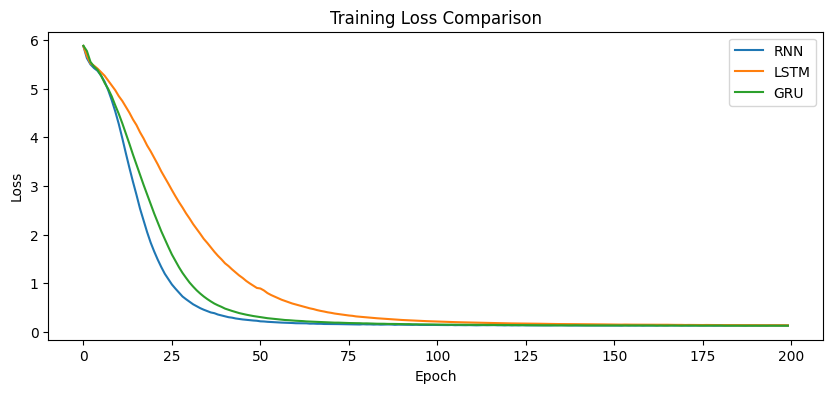

In [32]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [33]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [34]:
print("RNN :", generate_text(rnn_model, "Manish Kumar", 10))
print("LSTM:", generate_text(lstm_model, "Manish kumar", 10))
print("GRU :", generate_text(gru_model, "Manish Kumar", 10))

RNN : Manish Kumar learning eda and ai powered applications proficient in python scikit
LSTM: Manish kumar com 91 6204xxxx6 noida india linkedin github github github github
GRU : Manish Kumar data science intern cei — celebal excellence intern cei for


In [ ]:
# because may resume is not in proper in sequences so that we get some this

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**